**Общий план решения:**

**Генерация обучающих данных.** Обучающие данные буду генерировать синтетически: рисовать текст (слова, цены, телефоны, даты, коды и просто случайные строки) разными шрифтами на разных фонах и накладывать аугментации, имитирующие реальную фотографию объявления. Из плюсов это не привязывает меня ни к каким авторским правам

**Модели.** Буду сравнивать несколько лёгких CNN-бэкбонов (mobilenet, efficientnet-b0, mobilevit, resnet18 как более тяжёлый бейзлайн) из `timm`

**Воспроизводимость.** Всё, что генерируется автоматически, всегда получается одинаковым тк везде используется numpy.random.default_rng с заранее заданными seed: `SEED = 64` используется для обучающих данных, а также для генерации фонов и шрифтов, а `SEED + 1` для валидации

## 1. Генерация обучающийх данных

Тут моя цель - получить функцию `generate_sample`, которая по запросу отдаёт готовый обучающий пример: кроп текста на реалистичном фоне (или градиенте или цвете) и флаг, симметричен ли этот текст относительно поворота на 180. Размеченных реальных фото у нас нет, поэтому весь обучающий набор это синтетика. Чем разнообразнее шрифты, фоны, типы (слова / цены / телефоны / коды / случайный шум) и аугментации, тем лучше модель, обученная на такой синтетике, обобщится на настоящие кропы с объявлений

In [ ]:
!pip -q install wordfreq

In [ ]:
import os
import glob
import urllib.request
import random
from tqdm.auto import tqdm
import shutil
import time
import copy

import csv
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from wordfreq import top_n_list

import torchvision
from dataclasses import dataclass
from functools import lru_cache

In [ ]:
FONT_DIR = "/kaggle/working/fonts"
BG_DIR = "/kaggle/working/backgrounds"

os.makedirs(FONT_DIR, exist_ok=True)
os.makedirs(BG_DIR, exist_ok=True)

FONTS = [
    "https://github.com/google/fonts/raw/main/ofl/ptsans/PT_Sans-Web-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/ptserif/PT_Serif-Web-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/notosans/NotoSans%5Bwdth%2Cwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/montserrat/Montserrat%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/rubik/Rubik%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/firasans/FiraSans-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/playpensans/PlaypenSans%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/badscript/BadScript-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/caveat/Caveat%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/pacifico/Pacifico-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/lobster/Lobster-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/yesevaone/YesevaOne-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/philosopher/Philosopher-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/pattaya/Pattaya-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/oswald/Oswald%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/balsamiqsans/BalsamiqSans-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/bangers/Bangers-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/underdog/Underdog-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/comfortaa/Comfortaa%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/pangolin/Pangolin-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/pressstart2p/PressStart2P-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/roboto/Roboto%5Bwdth%2Cwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/roboto/Roboto-Italic%5Bwdth%2Cwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/robotocondensed/RobotoCondensed%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/opensans/OpenSans%5Bwdth%2Cwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/opensans/OpenSans-Italic%5Bwdth%2Cwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/inter/Inter%5Bopsz%2Cwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/ibmplexsans/IBMPlexSans%5Bwdth%2Cwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/nunito/Nunito%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/exo2/Exo2%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Bold.ttf",
    "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Italic.ttf",
    "https://github.com/google/fonts/raw/main/ofl/ptsansnarrow/PT_Sans-Narrow-Web-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/ptsansnarrow/PT_Sans-Narrow-Web-Bold.ttf",
    "https://github.com/google/fonts/raw/main/ofl/merriweather/Merriweather%5Bopsz%2Cwdth%2Cwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/lora/Lora%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/lora/Lora-Italic%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/playfairdisplay/PlayfairDisplay%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/sourceserif4/SourceSerif4%5Bopsz%2Cwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/cormorant/Cormorant%5Bwght%5D.ttf",
    "https://github.com/google/fonts/raw/main/ofl/anonymouspro/AnonymousPro-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/anonymouspro/AnonymousPro-Bold.ttf",
    "https://github.com/google/fonts/raw/main/ofl/marckscript/MarckScript-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/neucha/Neucha.ttf",
    "https://github.com/google/fonts/raw/main/ofl/amaticsc/AmaticSC-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/amaticsc/AmaticSC-Bold.ttf",
    "https://github.com/google/fonts/raw/main/ofl/russoone/RussoOne-Regular.ttf",
    "https://github.com/google/fonts/raw/main/ofl/ruslandisplay/RuslanDisplay-Regular.ttf",
]

for url in FONTS:
    name = url.split("/")[-1].replace("%5B", "[").replace("%5D", "]").replace("%2C", ",")
    dst = os.path.join(FONT_DIR, name)
    if not os.path.exists(dst):
        try:
            urllib.request.urlretrieve(url, dst)
        except Exception as e:
            print("не удалось скачать:", name, e)

In [ ]:
# качаю датасет DTD который по сути является просто банком фотографий фактур (дерево, ткань, металл и т.п.)
# потом буду использовать их как реалистичный фон под текстом

torchvision.datasets.DTD(root="/kaggle/working/dtd", download=True)
os.makedirs(BG_DIR, exist_ok=True)

for p in glob.glob("/content/dtd/dtd/images/**/*.jpg", recursive=True):
    shutil.copy(p, BG_DIR)

100%|██████████| 625M/625M [00:59<00:00, 10.5MB/s] 


In [ ]:
RU_LO = "абвгдеёжзийклмнопрстуфхцчшщъыьэюя"
RU_UP = RU_LO.upper()
EN_LO = "abcdefghijklmnopqrstuvwxyz"
EN_UP = EN_LO.upper()
DIG   = "0123456789"
PUNCT = ".,:;!?-_/()[]{}«»№#%$€₽"
SYM_ALPHAS = ["0689", "OXSZNHI", "ОХНИ", "808", "69", "0OoXx"]

In [ ]:
# если картинку перевернуть на 180°, некоторые символы будут выглядеть так же

ROT_MAP = {
    "0": "0", "8": "8", "6": "9", "9": "6",
    "o": "o", "O": "O", "x": "x", "X": "X", "s": "s", "S": "S", "z": "z", "Z": "Z",
    "N": "N", "H": "H", "I": "I", "l": "l",
    "u": "n", "n": "u", "p": "d", "d": "p", "b": "q", "q": "b",
    "О": "О", "о": "о", "Х": "Х", "х": "х", "Н": "Н", "н": "н", "И": "И",
    " ": " ", "-": "-", "=": "=", "+": "+", "/": "/", "|": "|", "%": "%", ":": ":",
}

def is_rot_symmetric(text: str) -> bool:
    if not text.strip():
        return True
    if any(c not in ROT_MAP for c in text):
        return False
    return "".join(ROT_MAP[c] for c in reversed(text)) == text

In [ ]:
RU_WORDS = [w for w in top_n_list("ru", 30000) if w.isalpha()]
EN_WORDS = [w for w in top_n_list("en", 30000) if w.isalpha()]

In [ ]:
def _pick(r, seq):
    return seq[int(r.integers(0, len(seq)))]


def _apply_case(r, s):
    m = r.random()
    if m < 0.25:
        return s.capitalize()
    if m < 0.40:
        return s.upper()
    return s


def _words(r, pool, k):
    return " ".join(_apply_case(r, _pick(r, pool)) for _ in range(k))


def _digits(r, n):
    return "".join(str(int(r.integers(0, 10))) for _ in range(n))


def _price(r):
    v = int(_pick(r, [r.integers(10, 1000), r.integers(1000, 100_000), r.integers(100_000, 5_000_000)]))
    s = f"{v:,}".replace(",", _pick(r, [" ", "", "."]))
    return s + _pick(r, [" ₽", "₽", " руб.", " руб", " р.", " р", "", " $", " €", " руб/мес"])


def _phone(r):
    return _pick(r, [
        f"+7 {_digits(r, 3)} {_digits(r, 3)}-{_digits(r, 2)}-{_digits(r, 2)}",
        f"8 ({_digits(r, 3)}) {_digits(r, 3)}-{_digits(r, 2)}-{_digits(r, 2)}",
        f"+7{_digits(r, 10)}",
        _digits(r, 11),
    ])


def _date(r):
    return f"{int(r.integers(1, 29)):02d}.{int(r.integers(1, 13)):02d}.{int(r.integers(1990, 2027))}"


def _code(r):
    alpha = _pick(r, [EN_UP, EN_UP + DIG, RU_UP + DIG, DIG, EN_LO + DIG])
    return "".join(_pick(r, alpha) for _ in range(int(r.integers(3, 10))))


def _random_string(r):
    m = r.random()
    if m < 0.40: alpha = RU_LO + RU_UP
    elif m < 0.65: alpha = EN_LO + EN_UP
    elif m < 0.80: alpha = DIG
    elif m < 0.90: alpha = RU_LO + DIG
    elif m < 0.97: alpha = EN_LO + DIG
    else: alpha = RU_LO + EN_LO
    n = int(_pick(r, [2, 3, 4, 5, 6, 8, 10, 12]))
    s = "".join(_pick(r, alpha) for _ in range(n))
    s = _apply_case(r, s)
    if r.random() < 0.20:
        sep = _pick(r, [" ", ".", "-", "/", ":", ","] + list(PUNCT))
        parts = ["".join(_pick(r, alpha) for _ in range(int(r.integers(1, 6)))) for _ in range(int(r.integers(2, 4)))]
        s = sep.join(parts)
    return s

In [ ]:
def sample_text(r):
    m = r.random()
    if m < 0.35 and RU_WORDS:
        return _words(r, RU_WORDS, int(_pick(r, [1, 1, 2, 2, 3])))
    if m < 0.50 and EN_WORDS:
        return _words(r, EN_WORDS, int(_pick(r, [1, 1, 2, 3])))
    if m < 0.60:
        return _price(r)
    if m < 0.68:
        return _phone(r)
    if m < 0.73:
        return _date(r)
    if m < 0.80:
        return _code(r)
    if m < 0.85:
        group = _pick(r, SYM_ALPHAS)
        return "".join(_pick(r, group) for _ in range(int(r.integers(2, 7))))
    if m < 0.88:
        return _pick(r, RU_LO + RU_UP + EN_LO + EN_UP + DIG)
    return _random_string(r)

In [ ]:
def try_render(ch, f):
    try:
        b = f.getbbox(ch)
        if b is None:
            return None
        w = max(b[2] - b[0], 1) + 2
        h = max(b[3] - b[1], 1) + 2
        im = Image.new("L", (w, h), 0)
        ImageDraw.Draw(im).text((1 - b[0], 1 - b[1]), ch, font=f, fill=255)
        a = np.asarray(im)
        return a if a.max() > 0 else None
    except Exception:
        return None

def _is_distinct(x, y):
    if x is None or y is None:
        return False
    if x.shape != y.shape:
        return True
    return not np.array_equal(x, y)

@lru_cache(maxsize=1)
def check_fonts(size=28):
    paths = glob.glob(os.path.join(FONT_DIR, "**", "*.ttf"), recursive=True)

    cyr, lat = [], []
    for p in sorted(set(paths)):
        try:
            f = ImageFont.truetype(p, size)
        except Exception:
            continue

        a = try_render("A",  f)
        g = try_render("g",  f)
        zh = try_render("Ж",  f)
        shch = try_render("щ",  f)

        lat_ok = _is_distinct(a, g)
        cyr_ok = _is_distinct(zh, shch)

        if cyr_ok:
            cyr.append(p)
        if lat_ok:
            lat.append(p)

    return cyr, lat

In [ ]:
@lru_cache(maxsize=512)
def _font(path, size):
     return ImageFont.truetype(path, size)

def _font_with_axes(r, path, size):
    f = ImageFont.truetype(path, size)
    try:
        axes = f.get_variation_axes()
        vals = [float(r.uniform(a["minimum"], a["maximum"])) for a in axes]
        f.set_variation_by_axes(vals)
    except Exception:
        pass
    return f

In [ ]:
@lru_cache(maxsize=1)
def _bg_images():
    out = []
    for p in glob.glob(os.path.join(BG_DIR, "**", "*.*"), recursive=True):
        im = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if im is not None and min(im.shape) >= 64:
            out.append(im)
    return out

def _make_bg(r, h, w):
    m = r.random()
    bgs = _bg_images()
    if m < 0.45 or not bgs:
        bg = np.full((h, w), int(r.integers(0, 256)), np.uint8)
    elif m < 0.70:
        a, b = int(r.integers(0, 256)), int(r.integers(0, 256))
        t = np.linspace(0, 1, w if r.random() < 0.5 else h, dtype=np.float32)
        g = (a + (b - a) * t).astype(np.uint8)
        bg = np.tile(g[None, :], (h, 1)) if len(g) == w else np.tile(g[:, None], (1, w))
    else:
        src = _pick(r, bgs)
        sh, sw = src.shape
        ch = int(r.integers(max(8, sh // 8), sh + 1))
        cw = int(r.integers(max(8, sw // 8), sw + 1))
        y0, x0 = int(r.integers(0, sh - ch + 1)), int(r.integers(0, sw - cw + 1))
        bg = cv2.resize(src[y0:y0 + ch, x0:x0 + cw], (w, h), interpolation=cv2.INTER_AREA)
        if r.random() < 0.5:
            bg = cv2.GaussianBlur(bg, (0, 0), float(r.uniform(1, 4)))
    return bg, int(np.median(bg))


def _pick_fg(r, bg_tone):
    if bg_tone >= 128:
        return int(r.integers(0, max(1, bg_tone - 60)))
    return int(r.integers(min(255, bg_tone + 60), 256))


In [ ]:
def _render(r, text, font, fg, bg_arr, neighbor_fonts=()):

    b = font.getbbox(text)
    tw, th = max(b[2] - b[0], 1), max(b[3] - b[1], 1)

    margin_x = int(tw * 0.6) + 20
    margin_y = int(th * 1.5) + 20
    W, H = tw + 2 * margin_x, th + 2 * margin_y

    canvas = Image.fromarray(cv2.resize(bg_arr, (W, H), interpolation=cv2.INTER_LINEAR))
    draw = ImageDraw.Draw(canvas)
    x0, y0 = margin_x - b[0], margin_y - b[1]

    stroke = int(_pick(r, [0, 0, 0, 1, 2]))
    if r.random() < 0.15:
        draw.text((x0 + 2, y0 + 2), text, font=font, fill=255 - fg)
    draw.text((x0, y0), text, font=font, fill=fg, stroke_width=stroke,
              stroke_fill=255 - fg if stroke and r.random() < 0.5 else fg)

    if r.random() < 0.35 and neighbor_fonts:
        gap = int(r.uniform(0.15, 0.6) * th)
        for sign in (-1, 1):
            if r.random() < 0.7:
                nf = _pick(r, neighbor_fonts)
                ntxt = sample_text(r)
                nb = nf.getbbox(ntxt)
                nh = max(nb[3] - nb[1], 1)
                ny = y0 + b[1] - gap - nh - nb[1] if sign < 0 else y0 + b[3] + gap - nb[1]
                nx = x0 + int(r.integers(-tw // 2, tw // 2 + 1)) if tw > 2 else x0
                draw.text((nx, ny), ntxt, font=nf, fill=fg)

    px_l = int(r.integers(-int(tw * 0.15), 14))
    px_r = int(r.integers(-int(tw * 0.15), 14))
    py_t = int(r.integers(-int(th * 0.2), int(th * 0.5) + 6))
    py_b = int(r.integers(-int(th * 0.2), int(th * 0.5) + 6))
    L = max(0, margin_x - px_l)
    R = min(W, margin_x + tw + px_r)
    T = max(0, margin_y - py_t)
    B = min(H, margin_y + th + py_b)
    if R - L < 4 or B - T < 4:
        return None
    return np.asarray(canvas)[T:B, L:R].copy()


def _augment(r, img, bg_tone):
    h, w = img.shape

    if r.random() < 0.6:
        ang = float(r.normal(0, 4.0))
        M = cv2.getRotationMatrix2D((w / 2, h / 2), ang, 1.0)
        img = cv2.warpAffine(img, M, (w, h), borderValue=bg_tone, borderMode=cv2.BORDER_REPLICATE)

    if r.random() < 0.3:
        sh = float(r.uniform(-0.35, 0.35))
        M = np.float32([[1, sh, -sh * h / 2], [0, 1, 0]])
        img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    if r.random() < 0.25:
        d = 0.08
        src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
        dst = src + np.float32(r.uniform(-d, d, (4, 2))) * np.float32([w, h])
        M = cv2.getPerspectiveTransform(src, dst)
        img = cv2.warpPerspective(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    if r.random() < 0.3:
        sx, sy = float(r.uniform(0.8, 1.2)), float(r.uniform(0.8, 1.2))
        img = cv2.resize(img, (max(4, int(w * sx)), max(4, int(h * sy))))

    if r.random() < 0.3:
        f = float(r.uniform(0.35, 0.8))
        small = cv2.resize(img, (max(4, int(img.shape[1] * f)), max(4, int(img.shape[0] * f))), interpolation=cv2.INTER_AREA)
        img = cv2.resize(small, (img.shape[1], img.shape[0]), interpolation=_pick(r, [cv2.INTER_LINEAR, cv2.INTER_NEAREST, cv2.INTER_CUBIC]))

    if r.random() < 0.4:
        k = int(_pick(r, [3, 5]))
        img = cv2.GaussianBlur(img, (k, k), float(r.uniform(0.3, 1.5)))

    if r.random() < 0.15:
        k = int(_pick(r, [3, 5, 7]))
        kern = np.zeros((k, k), np.float32)
        if r.random() < 0.5: kern[k // 2, :] = 1.0
        else: kern[:, k // 2] = 1.0
        img = cv2.filter2D(img, -1, kern / k)

    if r.random() < 0.6:
        a, b = float(r.uniform(0.7, 1.3)), float(r.uniform(-30, 30))
        img = np.clip(img.astype(np.float32) * a + b, 0, 255).astype(np.uint8)

    if r.random() < 0.4:
        noise = r.normal(0, float(r.uniform(2, 15)), img.shape)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    if r.random() < 0.5:
        q = int(r.integers(20, 90))
        ok, enc = cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, q])
        if ok:
            img = cv2.imdecode(enc, cv2.IMREAD_GRAYSCALE)

    if r.random() < 0.15:
        img = 255 - img

    return img


In [ ]:
@dataclass
class Sample:
    img: np.ndarray
    text: str
    symmetric: bool

In [ ]:
def generate_sample(r, text=None):
    cyr, lat = check_fonts()
    if text is None:
        text = sample_text(r)
    needs_cyr = any("\u0400" <= c <= "\u04ff" for c in text)
    pool = cyr if (needs_cyr and cyr) else (lat or cyr)
    font_path = _pick(r, pool)

    mode = r.random()
    if mode < 0.35:   size = int(r.integers(12, 25))
    elif mode < 0.8:  size = int(r.integers(24, 45))
    else:
      size = int(r.integers(44, 80))

    font = _font_with_axes(r, font_path, size) if r.random() < 0.5 else _font(font_path, size)

    bg_arr, bg_tone = _make_bg(r, 64, 256)
    fg = _pick_fg(r, bg_tone)

    neighbor_fonts = [_font(_pick(r, pool), int(size * float(r.uniform(0.6, 1.3)))) for _ in range(2)]
    img = _render(r, text, font, fg, bg_arr, neighbor_fonts)
    if img is None:
        return None
    img = _augment(r, img, bg_tone)
    return Sample(img=img, text=text, symmetric=is_rot_symmetric(text))

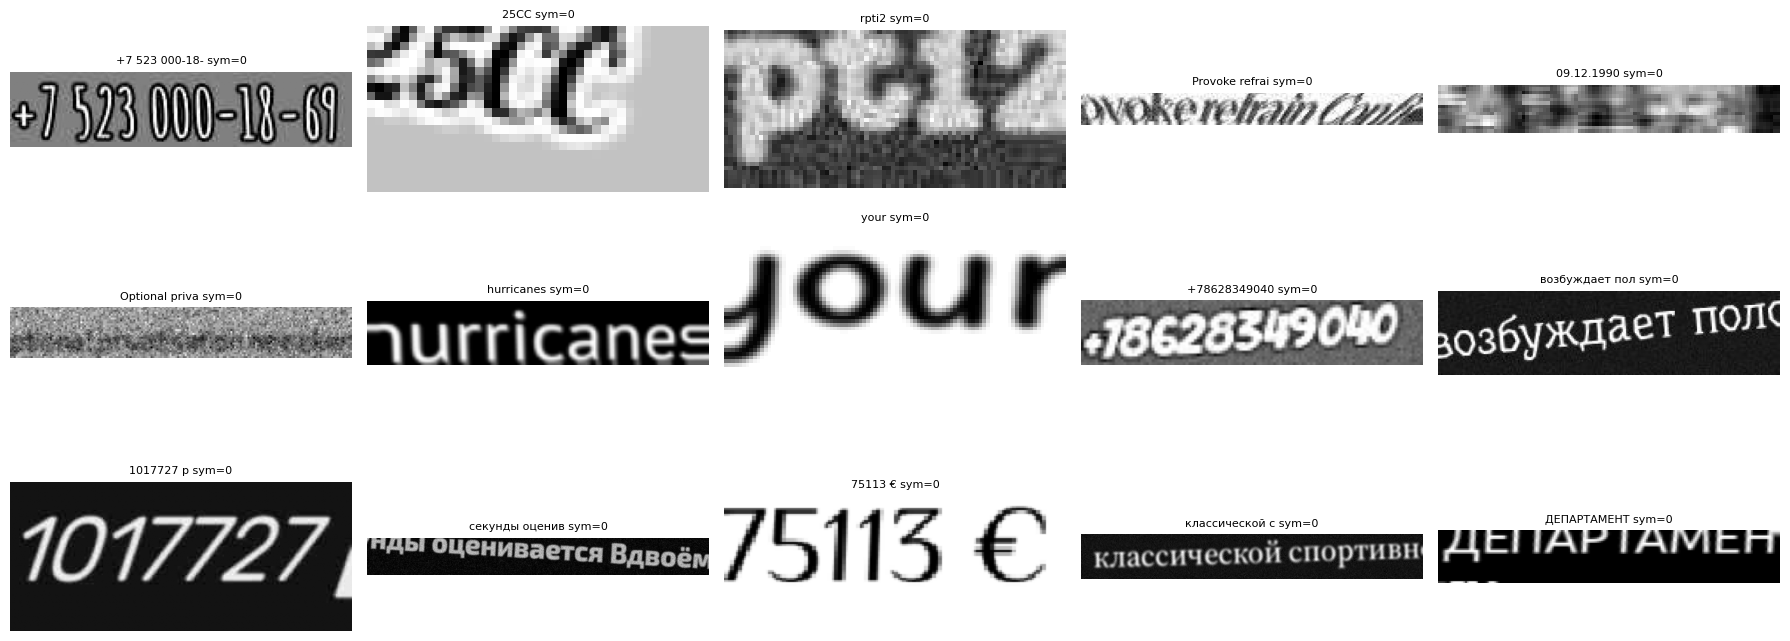

In [ ]:
r = np.random.default_rng(0)
fig, ax = plt.subplots(3, 5, figsize=(18, 7))
for a in ax.ravel():
    s = None
    while s is None:
        s = generate_sample(r)
    a.imshow(s.img, cmap="gray"); a.set_title(f"{s.text[:14]} sym={int(s.symmetric)}", fontsize=8); a.axis("off")
plt.tight_layout(); plt.show()

## 2. Создаю dataloader

Здесь `generate_sample` из раздела 1 оборачиваю в стандартные PyTorch `Dataset`/`DataLoader`. Трейн-датасет будет `IterableDataset` чтобы он не хранил заранее сгенерированные картинки, а генерировал новые случайные примеры на каждой эпохе. Валидационный датасет - один фиксированный набор из 5000 картинок, один раз сгенерированный и сохранённый на диск с отдельным seed'ом (`SEED + 1`), чтобы разные бэкбоны сравнивались строго на одних и тех же данных и сравнение было честным и воспроизводимым

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, IterableDataset

In [ ]:
IMG_H = 48
IMG_W = 256
STRIDE = 8

In [ ]:
def resize_pad(img: np.ndarray, rng=None):
    h, w = img.shape
    new_w = int(round(w * IMG_H / h))

    if new_w > IMG_W:
        img = cv2.resize(img, (new_w, IMG_H), interpolation=cv2.INTER_AREA)
        x0 = int(rng.integers(0, new_w - IMG_W + 1)) if rng is not None else (new_w - IMG_W) // 2
        return img[:, x0:x0 + IMG_W]

    img = cv2.resize(img, (max(1, new_w), IMG_H), interpolation=cv2.INTER_AREA)
    fill = int(np.median(np.concatenate([img[:, 0], img[:, -1]])))
    pad_l = (IMG_W - new_w) // 2

    return cv2.copyMakeBorder(img, 0, 0, pad_l, IMG_W - new_w - pad_l, cv2.BORDER_CONSTANT, value=fill)

def to_tensor(img: np.ndarray):
    return torch.from_numpy(np.ascontiguousarray(img)).float().div_(255.0).unsqueeze(0)

In [ ]:
class Dataset(IterableDataset):

    def __init__(self, seed: int, samples_per_epoch: int):
        self.seed = seed
        self.samples_per_epoch = samples_per_epoch

    def __iter__(self):
        info = torch.utils.data.get_worker_info()
        wid = info.id if info else 0
        nw = info.num_workers if info else 1
        rng = np.random.default_rng([self.seed, wid, int(time.time() * 1e6) % (2**31)])
        for _ in range(self.samples_per_epoch // nw):
            s = None
            while s is None:
                s = generate_sample(rng)
            rot = rng.random() < 0.5
            img = s.img[::-1, ::-1] if rot else s.img
            label = 0.5 if s.symmetric else float(rot)
            yield to_tensor(resize_pad(img, rng)), torch.tensor(label, dtype=torch.float32)


class ValDataset(Dataset):

    def __init__(self, df, img_dir):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(os.path.join(self.img_dir, row["image_id"]), cv2.IMREAD_GRAYSCALE)
        return to_tensor(resize_pad(img)), torch.tensor(float(row["label"]), dtype=torch.float32)

In [ ]:
def build_fixed_split(out_dir, n, seed):
    os.makedirs(out_dir, exist_ok=True)
    rng = np.random.default_rng(seed)
    rows = []
    for i in tqdm(range(n), desc=f"gen {out_dir}"):
        s = None
        while s is None:
            s = generate_sample(rng)
        rot = i % 2 == 1
        img = s.img[::-1, ::-1] if rot else s.img
        name = f"{i:06d}.png"
        cv2.imwrite(os.path.join(out_dir, name), np.ascontiguousarray(img))
        rows.append((name, 0.5 if s.symmetric else float(rot)))
    df = pd.DataFrame(rows, columns=["image_id", "label"])
    df.to_csv(os.path.join(out_dir, "labels.csv"), index=False)
    return df

In [ ]:
SEED = 64
BATCH_SIZE = 128
STEPS_PER_EPOCH = 400
NUM_WORKERS = os.cpu_count() or 2

VAL_DIR = "/kaggle/working/dataset/val_synth"
val_df = build_fixed_split(VAL_DIR, 5000, seed=SEED + 1)

train_ds = Dataset(seed=SEED, samples_per_epoch=STEPS_PER_EPOCH * BATCH_SIZE)
val_ds = ValDataset(val_df, VAL_DIR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=NUM_WORKERS)

gen /kaggle/working/dataset/val_synth:   0%|          | 0/5000 [00:00<?, ?it/s]

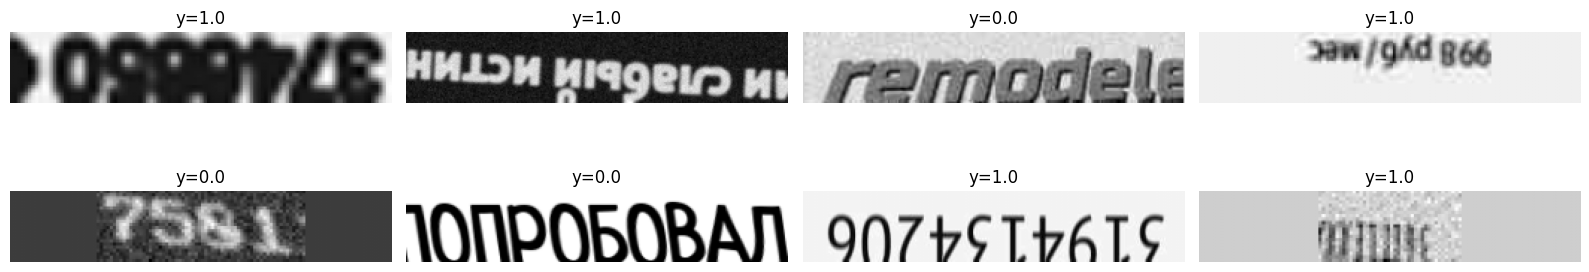

In [ ]:
x, y = next(iter(train_loader))
fig, ax = plt.subplots(2, 4, figsize=(16, 4))
for i, a in enumerate(ax.ravel()):
    a.imshow(x[i, 0], cmap="gray"); a.set_title(f"y={y[i].item():.1f}"); a.axis("off")
plt.tight_layout(); plt.show()

## 3. Модели

Буду сравнивать несколько лёгких бэкбонов из `timm` (`mobilenetv3_small_100`, `mobilenetv3_large_100`, `resnet18`, `efficientnet_b0`, `mobilevitv2_050`). Архитектура будет такая: бэкбон в режиме `features_only`, затем свёртка-шея, которая схлопывает признаки по высоте, и в конце голова которая превращает признаки в один скалярный скор. Финальный логит считается не напрямую, а как разность скора картинки и скора этой же картинки, перевёрнутой на 180.

In [ ]:
import timm
import torch.nn as nn

In [ ]:
class ModelBackbone(nn.Module):

    def __init__(self, name, pretrained=True, neck_channels=None):
        super().__init__()
        self.body = timm.create_model(name, features_only=True, in_chans=1, pretrained=pretrained, out_indices=(2,))
        cin = self.body.feature_info.channels()[0]
        cout = neck_channels or cin
        self.neck = nn.Sequential(
            nn.Conv2d(cin, cout, (IMG_H // STRIDE, 1), bias=False),
            nn.BatchNorm2d(cout),
            nn.Hardswish()
        )
        self.out_channels = cout

    def forward(self, x):
        return self.neck(self.body(x)[0])


class OrientModel(nn.Module):

    def __init__(self, backbone, pretrained=True):
        super().__init__()
        self.backbone = ModelBackbone(backbone, pretrained)
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(self.backbone.out_channels * 2, 1))
        self.register_buffer("temperature", torch.ones(1))

    @staticmethod
    def _normalize(x):
        m = x.mean(dim=(1, 2, 3), keepdim=True)
        s = x.std(dim=(1, 2, 3), keepdim=True).clamp_min(1e-3)
        return (x - m) / s

    def _score(self, x):
        f = self.backbone(x)
        v = torch.cat([f.mean(dim=(2, 3)), f.amax(dim=(2, 3))], 1)
        return self.head(v).squeeze(1)

    def forward(self, x):
        x = self._normalize(x)
        s = self._score(torch.cat([x, torch.flip(x, dims=(2, 3))], 0))
        b = x.shape[0]
        return s[:b] - s[b:]

    @torch.no_grad()
    def predict_proba(self, x, tta=True, clip=0.02):
        logits = self.forward(x)
        if tta:
            for dx in (-4, 4):
                logits = logits + self.forward(torch.roll(x, shifts=dx, dims=3))
            logits = logits / 3
        return torch.sigmoid(logits).clamp(clip, 1 - clip)


In [ ]:
BACKBONES = [
    "mobilenetv3_small_100",
    "mobilenetv3_large_100",
    "resnet18",
    "efficientnet_b0",
    "mobilevitv2_050",
]

## 4. Обучение

Каждый бэкбон из `BACKBONES` буду обучать одинаковое число эпох. Затем модели между собой сравниваю по двум осям: Brier score и latency на CPU и выберу разумный компромис.

In [ ]:
# Буду использовать усреднение весов моделей по последним шагам для стабильност и точности

class EMA:

    def __init__(self, model, decay=0.999):
        self.model = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.model.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for e, m in zip(self.model.state_dict().values(), model.state_dict().values()):
            if e.dtype.is_floating_point:
                e.mul_(self.decay).add_(m.detach(), alpha=1 - self.decay)
            else:
                e.copy_(m)

def brier(probs, targets):
    return float(torch.mean((probs - targets) ** 2))

In [ ]:
def train_one_epoch(model, ema, loader, optimizer, criterion, scheduler, scaler, device):

    model.train()
    probs, targets, losses = [], [], []

    for x, y in tqdm(loader, leave=False, total=STEPS_PER_EPOCH):

        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == "cuda"):  # CHANGED: AMP
            logits = model(x)

        loss = criterion(logits.float(), y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        scale_after = scaler.get_scale()

        if scale_after >= scale_before:
            scheduler.step()
        ema.update(model)
        losses.append(loss.item())
        probs.append(torch.sigmoid(logits.detach().float()).cpu()); targets.append(y.cpu())

    return brier(torch.cat(probs), torch.cat(targets)), float(np.mean(losses))

@torch.no_grad()
def valid_one_epoch(model, loader, criterion, device):

    model.eval()
    probs, targets, losses = [], [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x).float()
        losses.append(criterion(logits, y).item())
        probs.append(torch.sigmoid(logits).cpu()); targets.append(y.cpu())

    return brier(torch.cat(probs), torch.cat(targets)), float(np.mean(losses))

def fit_model(model, train_loader, val_loader, num_epochs, device, save_path, lr=1e-3, weight_decay=1e-2):

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, total_steps=num_epochs * STEPS_PER_EPOCH, pct_start=0.1)
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
    ema = EMA(model)

    history = {"train_brier": [], "val_brier": [], "ema_val_brier": []}
    best = float("inf")

    for epoch in range(num_epochs):
        t0 = time.time()
        tr_b, _ = train_one_epoch(model, ema, train_loader, optimizer, criterion, scheduler, scaler, device)
        va_b, _ = valid_one_epoch(model, val_loader, criterion, device)
        ema_b, _ = valid_one_epoch(ema.model, val_loader, criterion, device)
        for k, v in zip(history, (tr_b, va_b, ema_b)):
            history[k].append(v)
        print(f"[{epoch + 1:02d}/{num_epochs}] train={tr_b:.4f} val={va_b:.4f} ema_val={ema_b:.4f} ({time.time() - t0:.0f}s)")
        if ema_b < best:
            best = ema_b
            torch.save(ema.model.state_dict(), save_path)

    ema.model.load_state_dict(torch.load(save_path, map_location=device))

    return history, best, ema.model

In [ ]:
def measure_cpu_latency(model, input_size=(1, 1, IMG_H, IMG_W), n_runs=50):
    model = model.to('cpu').eval()
    dummy = torch.randn(*input_size)
    with torch.no_grad():
        for _ in range(5):
            model(dummy)
        start = time.time()
        for _ in range(n_runs):
            model(dummy)
        elapsed = time.time() - start
    return (elapsed / n_runs) * 1000

def model_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 10

results, trained = {}, {}
for backbone in BACKBONES:

    print(f"\n=== {backbone} ===")
    model = OrientModel(backbone, pretrained=True).to(DEVICE)
    history, best, ema_model = fit_model(model, train_loader, val_loader, EPOCHS, DEVICE, f"best_{backbone}.pth")

    trained[backbone] = ema_model
    results[backbone] = {"history": history, "best_val_brier": best, "cpu_latency_ms": measure_cpu_latency(ema_model)}

    print(f"best_val_brier={best:.4f}  cpu_latency={results[backbone]['cpu_latency_ms']:.1f} ms")


=== mobilenetv3_small_100 ===


Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


  0%|          | 0/400 [00:00<?, ?it/s]

[01/10] train=0.2521 val=0.2320 ema_val=0.2551 (113s)


  0%|          | 0/400 [00:00<?, ?it/s]

...

[08/10] train=0.0668 val=0.0603 ema_val=0.0661 (115s)


  0%|          | 0/400 [00:00<?, ?it/s]

[09/10] train=0.0644 val=0.0589 ema_val=0.0633 (116s)


  0%|          | 0/400 [00:00<?, ?it/s]

[10/10] train=0.0625 val=0.0586 ema_val=0.0616 (115s)
best_val_brier=0.0616  cpu_latency=12.7 ms


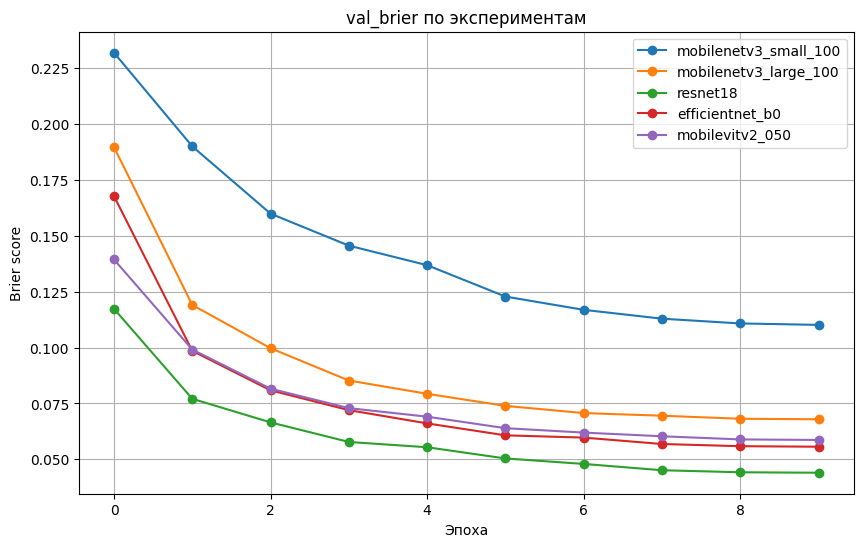

In [ ]:
plt.figure(figsize=(10, 6))
for name, res in results.items():
    history = res['history']
    if 'val_brier' in history:
        plt.plot(history['val_brier'], marker='o', label=name)

plt.xlabel('Эпоха')
plt.ylabel('Brier score')
plt.title('val_brier по экспериментам')
plt.grid(True)
plt.legend()
plt.show()

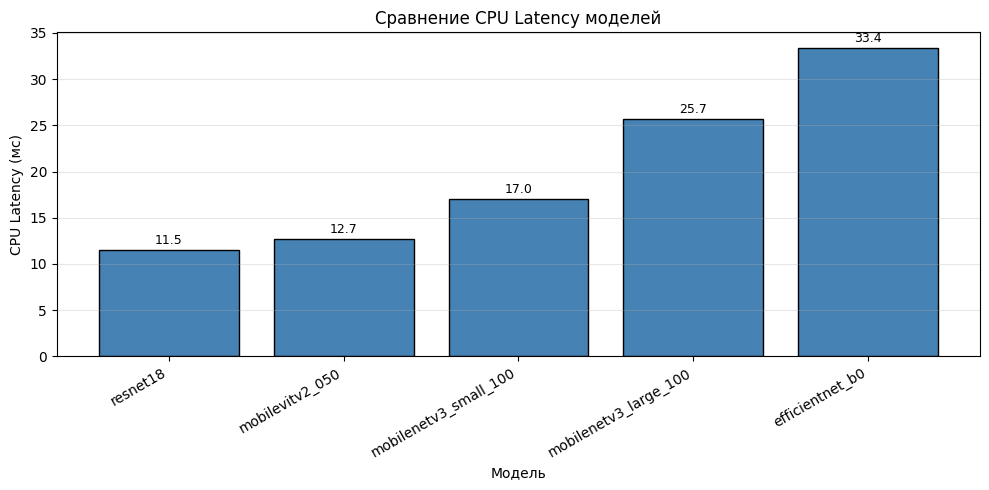

In [ ]:
models = list(results.keys())
latencies = [results[m]['cpu_latency_ms'] for m in models]

sorted_pairs = sorted(zip(models, latencies), key=lambda x: x[1])
models_sorted, latencies_sorted = zip(*sorted_pairs)

plt.figure(figsize=(10, 5))
bars = plt.bar(models_sorted, latencies_sorted,
               color='steelblue', edgecolor='black')

for bar, val in zip(bars, latencies_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, val + max(latencies_sorted)*0.01,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Модель')
plt.ylabel('CPU Latency (мс)')
plt.title('Сравнение CPU Latency моделей')
plt.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. Результат

В качестве финального бэкбона выбираю `resnet18`. По результам он даёт лучший баланс между Brier score на валидации и скоростью инференса на CPU

In [ ]:
!gdown 1ONORGFcEXZv5EVutnKbji1NzgX2dVS5t

Downloading...
From (original): https://drive.google.com/uc?id=1ONORGFcEXZv5EVutnKbji1NzgX2dVS5t
From (redirected): https://drive.google.com/uc?id=1ONORGFcEXZv5EVutnKbji1NzgX2dVS5t&confirm=t&uuid=c146790a-1020-4f73-b97f-c013f887b1d5
To: /kaggle/working/test.zip
100%|████████████████████████████████████████| 681M/681M [00:13<00:00, 48.8MB/s]


In [ ]:
import zipfile

In [ ]:
!unzip -q "/kaggle/working/test.zip" -d //kaggle/working

In [ ]:
TEST_DIR = '/kaggle/working/test/images'

In [ ]:
class TestDataset(Dataset):
    def __init__(self, img_dir):
        self.img_dir = img_dir
        self.filenames = sorted(
            f for f in os.listdir(img_dir)
            if f.lower().endswith(".png")
        )

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]
        img = cv2.imread(os.path.join(self.img_dir, name), cv2.IMREAD_GRAYSCALE)
        return to_tensor(resize_pad(img)), name


test_ds = TestDataset(TEST_DIR)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)
print("тестовых кропов:", len(test_ds))

тестовых кропов: 20000


In [ ]:
BEST_BACKBONE = "resnet18"
CKPT_PATH = f"best_{BEST_BACKBONE}.pth"

model = OrientModel(backbone=BEST_BACKBONE).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

AvitoModel(
  (backbone): AvitoBackbone(
    (body): FeatureListNet(
      (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (drop_block): Identity()
          (act1): ReLU(inplace=True)
          (aa): Identity()
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act2): ReLU(inplace=True)
        )
        (1): BasicBlock(
         

In [ ]:
image_ids, pred = [], []

with torch.no_grad():
    for x_batch, names in tqdm(test_loader):
        x_batch = x_batch.to(DEVICE)
        p = model.predict_proba(x_batch)
        pred.extend(p.cpu().numpy().tolist())
        image_ids.extend(names)

print("готово, примеров:", len(image_ids))

  0%|          | 0/79 [00:00<?, ?it/s]

готово, примеров: 20000


In [ ]:
images = [os.path.splitext(img)[0] for img in image_ids]

In [ ]:
submission = pd.DataFrame({"image_id": images, "p_180": pred})
submission.to_csv("/kaggle/working/submission.csv", index=False)
submission.head()

,image_id,p_180
0,test_00000,0.026620
1,test_00001,0.980000
2,test_00002,0.980000
3,test_00003,0.351745
4,test_00004,0.980000
